# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

In [3]:
!pip install sqlalchemy 
!pip install psycopg2-binary 
import pandas as pd
from sqlalchemy import create_engine 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [5]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [6]:
engine = create_engine(connection_string) 


In [7]:
query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
),
base_orders AS (
  SELECT
    *,
    (created_dt_msk::date - LAG(created_dt_msk::date) OVER (
      PARTITION BY user_id
      ORDER BY created_dt_msk ASC, created_ts_msk ASC, order_id ASC
    ))::integer AS days_since_prev
  FROM afisha.purchases
  WHERE device_type_canonical IN ('mobile', 'desktop')
)
SELECT
  bo.user_id,
  bo.device_type_canonical,
  bo.order_id,
  bo.created_dt_msk AS order_dt,
  bo.created_ts_msk AS order_ts,
  bo.currency_code,
  bo.revenue,
  bo.tickets_count,
  bo.days_since_prev,
  bo.event_id,
  e.event_name_code AS event_name,
  e.event_type_main,
  bo.service_name,
  r.region_name,
  c.city_name
FROM base_orders bo
CROSS JOIN set_config_precode
JOIN afisha.events e
  ON e.event_id = bo.event_id
JOIN afisha.city c
  ON c.city_id = e.city_id
JOIN afisha.regions r
  ON r.region_id = c.region_id
WHERE e.event_type_main <> 'Фильмы'
ORDER BY
  bo.user_id ASC,
  bo.created_dt_msk ASC,
  bo.created_ts_msk ASC,
  bo.order_id ASC

'''

df = pd.read_sql_query(query, con=engine)

Добавил библиотеки и сделал выгрузку SQL‑запроса с данными, с которыми буду работать.


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [8]:
print("shape:", df.shape)
print("columns:", list(df.columns))

display(df.head(10))
df.info()

display(df.isna().sum())

shape: (290849, 15)
columns: ['user_id', 'device_type_canonical', 'order_id', 'order_dt', 'order_ts', 'currency_code', 'revenue', 'tickets_count', 'days_since_prev', 'event_id', 'event_name', 'event_type_main', 'service_name', 'region_name', 'city_name']


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Облачко,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,театр,Лучшие билеты,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,NaN,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерты,Лови билет!,Широковская область,Радужнополье


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290849 non-null  object        
 1   device_type_canonical  290849 non-null  object        
 2   order_id               290849 non-null  int64         
 3   order_dt               290849 non-null  datetime64[ns]
 4   order_ts               290849 non-null  datetime64[ns]
 5   currency_code          290849 non-null  object        
 6   revenue                290849 non-null  float64       
 7   tickets_count          290849 non-null  int64         
 8   days_since_prev        268909 non-null  float64       
 9   event_id               290849 non-null  int64         
 10  event_name             290849 non-null  object        
 11  event_type_main        290849 non-null  object        
 12  service_name           290849 non-null  obje

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21940
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
dtype: int64

days_since_prev содержит пропуски, типа данные верные 

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [9]:


url = "https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv"
rates = pd.read_csv(url)

rates_small = pd.DataFrame({
    "date_norm": pd.to_datetime(rates.iloc[:, 0]).dt.normalize(),
    "nominal": rates.iloc[:, 1].astype(float),
    "rate": rates.iloc[:, 2].astype(float),
    "currency": rates.iloc[:, 3].astype(str).str.lower()
})

rates_nominal = float(rates_small["nominal"].iloc[0])  
rates_small = rates_small.query("currency == 'kzt'")[["date_norm", "rate"]].drop_duplicates()

df["order_dt_norm"] = pd.to_datetime(df["order_dt"]).dt.normalize()
df = df.merge(rates_small, how="left", left_on="order_dt_norm", right_on="date_norm")

df["revenue_rub"] = np.where(
    df["currency_code"].str.lower().eq("kzt"),
    df["revenue"] * df["rate"] / rates_nominal,
    df["revenue"]
)

df = df.drop(columns=["order_dt_norm", "date_norm", "rate"])

In [10]:
print("revenue_rub NaNs:", df["revenue_rub"].isna().sum())
print(df[["currency_code","revenue","revenue_rub"]].head(10))

rub_diff = (df.loc[df["currency_code"].str.lower().eq("rub"), "revenue_rub"] -
            df.loc[df["currency_code"].str.lower().eq("rub"), "revenue"]).abs().max()
print("max abs diff for RUB:", rub_diff)

kzt_cnt = df.loc[df["currency_code"].str.lower().eq("kzt")].shape[0]
kzt_changed = (df.loc[df["currency_code"].str.lower().eq("kzt"), "revenue_rub"] -
               df.loc[df["currency_code"].str.lower().eq("kzt"), "revenue"]).abs().gt(1e-9).mean()
print("KZT rows:", kzt_cnt, "fraction changed:", kzt_changed)

print("shape:", df.shape)

revenue_rub NaNs: 0
  currency_code  revenue  revenue_rub
0           rub  1521.94      1521.94
1           rub   289.45       289.45
2           rub  1258.57      1258.57
3           rub     8.49         8.49
4           rub  1390.41      1390.41
5           rub   902.74       902.74
6           rub   917.83       917.83
7           rub    47.78        47.78
8           rub    74.84        74.84
9           rub  1421.91      1421.91
max abs diff for RUB: 0.0
KZT rows: 5069 fraction changed: 0.998816334582758
shape: (290849, 16)


In [11]:
df["currency_code"].value_counts()

rub    285780
kzt      5069
Name: currency_code, dtype: int64

revenue_rub посчитан без пропусков

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [12]:
missing = df.isna().sum().sort_values(ascending=False)
missing

days_since_prev          21940
user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

In [13]:
df["order_dt"] = pd.to_datetime(df["order_dt"], errors="coerce")
df["order_ts"] = pd.to_datetime(df["order_ts"], errors="coerce")

df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce").astype("float32")
df["revenue_rub"] = pd.to_numeric(df["revenue_rub"], errors="coerce").astype("float32")
df["tickets_count"] = pd.to_numeric(df["tickets_count"], errors="coerce").astype("int32")
df["days_since_prev"] = pd.to_numeric(df["days_since_prev"], errors="coerce").astype("float32")

df["order_id"] = pd.to_numeric(df["order_id"], errors="coerce").astype("int64")
df["event_id"] = pd.to_numeric(df["event_id"], errors="coerce").astype("int64")

In [14]:
obj_cols = df.select_dtypes(include="object").columns
bad_markers = {"none","null","nan","n/a","na","нет","","missing"}
for col in obj_cols:
    vals = df[col].astype(str).str.lower()
    hits = vals[vals.isin(bad_markers)].unique()
    if len(hits) > 0:
        print(col, "markers:", hits[:10])

In [15]:
df[obj_cols] = df[obj_cols].replace(
    to_replace=list(bad_markers), value=pd.NA, regex=False
)
for col in obj_cols:
    df[col] = df[col].astype("category")

In [16]:
df[["revenue_rub","tickets_count","days_since_prev"]].describe(percentiles=[0.01,0.05,0.5,0.95,0.99])

p99 = df["revenue_rub"].quantile(0.99)
p99

2628.421630859375

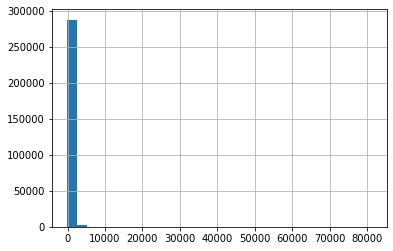

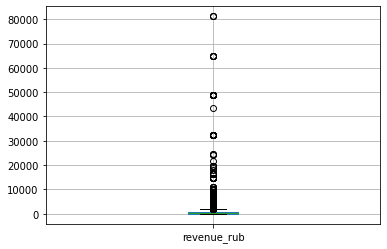

In [17]:


df["revenue_rub"].hist(bins=30)
plt.show()

df.boxplot(column="revenue_rub")
plt.show()

In [18]:
n0 = len(df)
out_cnt = (df["revenue_rub"] > p99).sum()

df = df[df["revenue_rub"] <= p99].copy()

n1 = len(df)
print("original:", n0, "kept:", n1, "removed:", n0-n1, "out_cnt:", out_cnt)

original: 290849 kept: 288024 removed: 2825 out_cnt: 2825


данные готовы к анализу, новый признак revenue_rub без пропусков, а выбросы по выручке отсечены по 99 перцентилю.


---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [19]:
df_prof = df.sort_values(["user_id", "order_ts"]).copy()

df_prof["gap_days"] = df_prof.groupby("user_id")["order_ts"].diff().dt.total_seconds() / 86400

profile = (
    df_prof.groupby("user_id")
    .agg(
        first_order_dt=("order_dt", "first"),
        last_order_dt=("order_dt", "last"),
        first_device_type=("device_type_canonical", "first"),
        first_region_name=("region_name", "first"),
        first_service_name=("service_name", "first"),
        first_event_type_main=("event_type_main", "first"),
        total_orders=("order_id", "count"),
        avg_revenue_per_order_rub=("revenue_rub", "mean"),
        avg_tickets_per_order=("tickets_count", "mean"),
        avg_time_between_orders=("gap_days", "mean"),
    )
    .reset_index()
)

profile["is_two"] = (profile["total_orders"] >= 2).astype(int)
profile["is_five"] = (profile["total_orders"] >= 5).astype(int)

profile.head()

,user_id,first_order_dt,last_order_dt,first_device_type,first_region_name,first_service_name,first_event_type_main,total_orders,avg_revenue_per_order_rub,avg_tickets_per_order,avg_time_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.939941,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010010,3.000000,74.805301,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213318,2.666667,50.906667,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830017,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.309998,1.500000,15.617963,1,0


In [20]:
print("profile shape:", profile.shape)
print("users:", profile["user_id"].nunique())
print("NaNs in avg_time_between_orders:", profile["avg_time_between_orders"].isna().sum())
print("share is_two:", profile["is_two"].mean())
print("share is_five:", profile["is_five"].mean())

profile shape: (21940, 13)
users: 21940
NaNs in avg_time_between_orders: 8446
share is_two: 0.6150410209662717
share is_five: 0.2892433910665451


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [21]:
n_users = profile["user_id"].nunique()
avg_rev_per_order = df["revenue_rub"].mean()

share_2plus = profile["is_two"].mean()
share_5plus = profile["is_five"].mean()

print("users:", n_users)
print("avg revenue per order (rub):", avg_rev_per_order)
print("share users >=2 orders:", share_2plus)
print("share users >=5 orders:", share_5plus)

cols_stats = ["total_orders", "avg_tickets_per_order", "avg_time_between_orders"]
for c in cols_stats:
    s = profile[c].dropna()
    print("\n", c)
    print(s.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

users: 21940
avg revenue per order (rub): 517.61206
share users >=2 orders: 0.6150410209662717
share users >=5 orders: 0.2892433910665451

 total_orders
count    21940.000000
mean        13.127803
std        121.522502
min          0.000000
1%           1.000000
5%           1.000000
50%          2.000000
95%         31.000000
99%        151.610000
max      10188.000000
Name: total_orders, dtype: float64

 avg_tickets_per_order
count    21861.000000
mean         2.742758
std          0.912988
min          1.000000
1%           1.000000
5%           1.000000
50%          2.750000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets_per_order, dtype: float64

 avg_time_between_orders
count    13494.000000
mean        15.881819
std         22.276639
min          0.000012
1%           0.000590
5%           0.001285
50%          8.123640
95%         61.406008
99%        112.118757
max        148.227755
Name: avg_time_between_orders, dtype: float64


In [22]:
p99_orders = profile["total_orders"].quantile(0.99)
p99_tickets = profile["avg_tickets_per_order"].quantile(0.99)

outlier_users = profile[
    (profile["total_orders"] > p99_orders) |
    (profile["avg_tickets_per_order"] > p99_tickets)
].shape[0]

print("p99 total_orders:", p99_orders)
print("p99 avg_tickets_per_order:", p99_tickets)
print("outlier users (за p99 по orders/tickets):", outlier_users)

profile_f = profile[
    (profile["total_orders"] <= p99_orders) &
    (profile["avg_tickets_per_order"] <= p99_tickets)
].copy()

orders_before = df.shape[0]
orders_after = df[df["user_id"].isin(profile_f["user_id"])].shape[0]

print("orders before:", orders_before, "after:", orders_after, "removed:", orders_before - orders_after)
print("users before:", profile.shape[0], "after:", profile_f.shape[0], "removed:", profile.shape[0] - profile_f.shape[0])

df_f = df[df["user_id"].isin(profile_f["user_id"])].copy()

print("\nAfter filtering:")
print("users:", profile_f["user_id"].nunique())
print("avg revenue per order (rub):", df_f["revenue_rub"].mean())
print("share users >=2 orders:", profile_f["is_two"].mean())
print("share users >=5 orders:", profile_f["is_five"].mean())

p99 total_orders: 151.61000000000058
p99 avg_tickets_per_order: 5.0
outlier users (за p99 по orders/tickets): 414
orders before: 288024 after: 139860 removed: 148164
users before: 21940 after: 21447 removed: 493

After filtering:
users: 21447
avg revenue per order (rub): 520.71356
share users >=2 orders: 0.615983587448128
share users >=5 orders: 0.28516808877698513


В профиле 21940 пользователей.
Доля с >=2 заказами — 0.615, с >=5 заказами — 0.289.
avg_time_between_orders имеет NaN у 8446 пользователей — нормально, у них total_orders = 1, интервала между заказами нет.




---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [23]:
features = [
    ("first_event_type_main", "тип первого мероприятия"),
    ("first_device_type", "устройство первого заказа"),
    ("first_region_name", "регион первого заказа"),
    ("first_service_name", "оператор первого заказа"),
]

n = len(profile)

for col, title in features:
    dist = (profile[col]
            .value_counts(dropna=False)
            .rename("users")
            .to_frame()
           )
    dist["share"] = dist["users"] / n
    dist = dist.sort_values("users", ascending=False)

    print("\n", title, f"(всего пользователей: {n})")
    display(dist.head(15))

    print("Макс. сегмент:", dist.index[0], "users:", dist.iloc[0,0], "share:", dist.iloc[0,1])


 тип первого мероприятия (всего пользователей: 21940)


,users,share
концерты,9637,0.439243
другое,5483,0.249909
театр,4285,0.195305
стендап,1115,0.050820
спорт,801,0.036509
выставки,418,0.019052
ёлки,95,0.004330
NaN,79,0.003601
фильм,27,0.001231


Макс. сегмент: концерты users: 9637 share: 0.43924339106654514

 устройство первого заказа (всего пользователей: 21940)


,users,share
mobile,18118,0.825798
desktop,3743,0.170602
NaN,79,0.003601


Макс. сегмент: mobile users: 18118 share: 0.8257976298997265

 регион первого заказа (всего пользователей: 21940)


,users,share
Каменевский регион,7169,0.326755
Североярская область,3801,0.173245
Широковская область,1236,0.056335
Озернинский край,678,0.030902
Малиновоярский округ,528,0.024066
Шанырский регион,503,0.022926
Травяная область,493,0.022470
Светополянский округ,464,0.021149
Речиновская область,446,0.020328
Яблоневская область,416,0.018961


Макс. сегмент: Каменевский регион users: 7169 share: 0.32675478577939837

 оператор первого заказа (всего пользователей: 21940)


,users,share
Билеты без проблем,5236,0.238651
Мой билет,2992,0.136372
Лови билет!,2846,0.129717
Билеты в руки,2594,0.118232
Облачко,2192,0.099909
Весь в билетах,1302,0.059344
Лучшие билеты,1192,0.054330
Прачечная,588,0.026800
Край билетов,457,0.020830
Дом культуры,357,0.016272


Макс. сегмент: Билеты без проблем users: 5236 share: 0.23865086599817684


 пользователи не распределены равномерно, есть выраженные точки входа — прежде всего mobile и крупные операторы/типы (концерты и “Билеты без проблем”).

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Overall share (>=2 orders): 0.615983587448128

Первое мероприятие: сегменты выше среднего


,first_event_type_main,users,share_2plus
6,фильм,27,0.814815
0,выставки,411,0.639903
5,театр,4199,0.637056
2,концерты,9506,0.619083


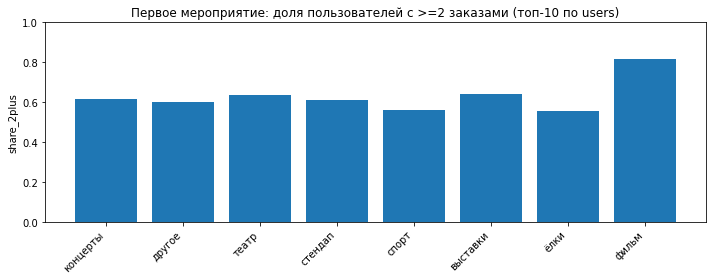


Устройство первого заказа: сегменты выше среднего


,first_device_type,users,share_2plus
0,desktop,3670,0.640872


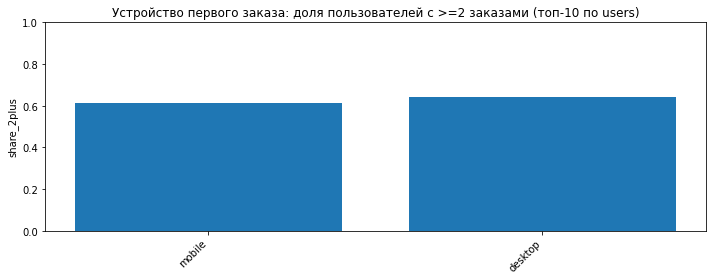


Регион первого заказа: сегменты выше среднего


,first_region_name,users,share_2plus
5,Верхозёрский край,1,1.000000
46,Озернопольская область,28,0.892857
51,Радужнопольский край,23,0.782609
36,Лесостепной край,59,0.728814
12,Горноземский регион,28,0.714286
11,Горицветская область,245,0.673469
76,Шанырский регион,500,0.672000
33,Лесноярский край,3,0.666667
71,Тихолесский край,9,0.666667
79,Ягодиновская область,63,0.666667


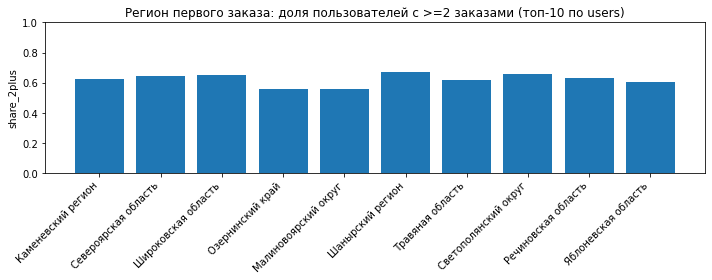


Оператор первого заказа: сегменты выше среднего


,first_service_name,users,share_2plus
14,Зе Бест!,1,1.000000
6,Быстрый кассир,61,0.852459
2,Билет по телефону,6,0.833333
26,Реестр,33,0.818182
0,Crazy ticket!,45,0.688889
8,Восьмёрка,85,0.682353
12,Дом культуры,352,0.650568
27,Росбилет,40,0.650000
1,Show_ticket,157,0.649682
17,Край билетов,450,0.648889


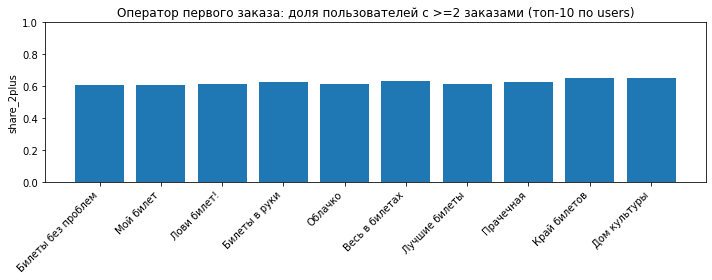

In [24]:


prof = profile_f if "profile_f" in globals() else profile

overall = prof["is_two"].mean()
print("Overall share (>=2 orders):", overall)

features = [
    ("first_event_type_main", "Первое мероприятие"),
    ("first_device_type", "Устройство первого заказа"),
    ("first_region_name", "Регион первого заказа"),
    ("first_service_name", "Оператор первого заказа"),
]

def plot_segments(feature, title, top_n=10):
    x = prof[[feature, "is_two"]].copy()
    x[feature] = x[feature].fillna("NaN")  

    agg = (x.groupby(feature)
             .agg(users=( "is_two","size"),
                  share_2plus=("is_two","mean"))
             .reset_index()
           )

    above = agg[agg["share_2plus"] > overall].sort_values("share_2plus", ascending=False)
    print(f"\n{title}: сегменты выше среднего")
    display(above.head(10))

    plot_df = agg.sort_values("users", ascending=False).head(top_n)

    plt.figure(figsize=(10, 4))
    plt.bar(plot_df[feature].astype(str), plot_df["share_2plus"] )
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.title(f"{title}: доля пользователей с >=2 заказами (топ-{top_n} по users)")
    plt.ylabel("share_2plus")
    plt.tight_layout()
    plt.show()

for feature, title in features:
    plot_segments(feature, title, top_n=10)

Чаще возвращаются сегменты с долей повторных заказов выше среднего (~0.616): по первому мероприятию лидируют фильм, выставки, театр, концерты; по устройству — desktop. Есть «точки входа» с долями выше среднего, но часть из них может быть нестабильной из‑за маленьких размеров сегментов.


---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Гипотеза 1 (спорт > концерты) не подтверждается: среди сегментов с долей повторных заказов выше среднего есть концерты , театр , выставки , но спорт не проявился как более активный по возвратам, чем концерты.

Гипотеза 2 (популярные регионы > менее активных) не подтверждается: лидер по числу пользователей — Каменевский регион (~32.7%), но повышенная доля повторных заказов наблюдается в отдельных, часто небольших по размеру сегментах, а не в крупнейшем регионе.


---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


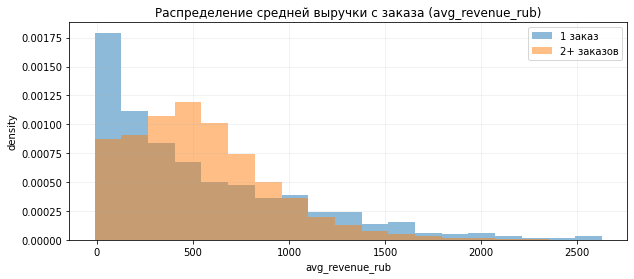

1 заказ: count 8236 median 373.98 mean 541.5807
2+ заказов: count 13211 median 494.658 mean 542.2458


In [25]:

prof = profile_f if "profile_f" in globals() else profile

# имя столбца из вашей задачи 3.1: avg_revenue_per_order_rub
avg_col = "avg_revenue_per_order_rub"
if avg_col not in prof.columns:
    avg_col = "avg_revenue_rub"  # на случай если у вас другое имя

g1 = prof.loc[prof["is_two"] == 0, avg_col].dropna()  # 1 заказ
g2 = prof.loc[prof["is_two"] == 1, avg_col].dropna()  # 2+ заказов

bins = np.linspace(prof[avg_col].min(), prof[avg_col].max(), 20)

plt.figure(figsize=(10, 4))
plt.hist(g1, bins=bins, alpha=0.5, density=True, label="1 заказ")
plt.hist(g2, bins=bins, alpha=0.5, density=True, label="2+ заказов")
plt.legend()
plt.title("Распределение средней выручки с заказа (avg_revenue_rub)")
plt.xlabel("avg_revenue_rub")
plt.ylabel("density")
plt.grid(alpha=0.2)
plt.show()

print("1 заказ: count", len(g1), "median", g1.median(), "mean", g1.mean())
print("2+ заказов: count", len(g2), "median", g2.median(), "mean", g2.mean())

Распределения разные: по медиане пользователи с 2+ заказами в среднем имеют выше avg_revenue_rub, чем с 1 заказом (примерно на 121 руб). Среднее почти одинаковое (541.6 vs 542.2), значит основное отличие связано с формой распределений (перекос/хвосты), а не с разницей средних.



---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


2-4 mean: 548.76263 median: 470.405
5+  mean: 534.6858 median: 511.80484


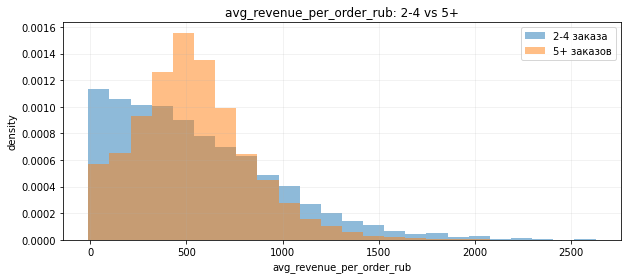

In [26]:
col = "avg_revenue_per_order_rub"

g_2_4 = profile_f.loc[profile_f["total_orders"].between(2, 4), col].dropna()
g_5p  = profile_f.loc[profile_f["total_orders"] >= 5, col].dropna()

print("2-4 mean:", g_2_4.mean(), "median:", g_2_4.median())
print("5+  mean:", g_5p.mean(),  "median:", g_5p.median())

import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(profile_f[col].min(), profile_f[col].max(), 25)

plt.figure(figsize=(10,4))
plt.hist(g_2_4, bins=bins, alpha=0.5, density=True, label="2-4 заказа")
plt.hist(g_5p,  bins=bins, alpha=0.5, density=True, label="5+ заказов")
plt.legend()
plt.title("avg_revenue_per_order_rub: 2-4 vs 5+")
plt.xlabel("avg_revenue_per_order_rub")
plt.ylabel("density")
plt.grid(alpha=0.2)
plt.show()

2–4 заказа: среднее 548.76, медиана 470.41
5+ заказа: среднее 534.69, медиана 511.80

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

overall share >=2: 0.615983587448128


,tickets_segment,users,share_2plus
0,1-2,6161.0,0.401558
1,2-3,9940.0,0.742656
2,3-5,5346.0,0.627572
3,5+,NaN,NaN


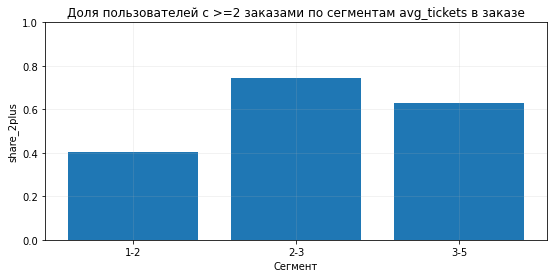

In [27]:


prof = profile_f if "profile_f" in globals() else profile

col = "avg_tickets_count" if "avg_tickets_count" in prof.columns else "avg_tickets_per_order"

overall = prof["is_two"].mean()

bins = [1, 2, 3, 5, float("inf")]
labels = ["1-2", "2-3", "3-5", "5+"]

tmp = prof.dropna(subset=[col]).copy()
tmp["tickets_segment"] = pd.cut(tmp[col], bins=bins, labels=labels, include_lowest=True, right=True)

seg = (tmp.groupby("tickets_segment", observed=True)
         .agg(users=("user_id","count"), share_2plus=("is_two","mean"))
         .reindex(labels)
         .reset_index()
      )

print("overall share >=2:", overall)
display(seg)

# График
plt.figure(figsize=(9,4))
plt.bar(seg["tickets_segment"].astype(str), seg["share_2plus"])
plt.ylim(0, 1)
plt.title("Доля пользователей с >=2 заказами по сегментам avg_tickets в заказе")
plt.ylabel("share_2plus")
plt.xlabel("Сегмент")
plt.grid(alpha=0.2)
plt.show()

По доле повторных покупок:
2–3: ~0.743 (выше среднего)
3–5: ~0.628
1–2: ~0.402 (заметно ниже среднего)
5+: сегмента нет в данных (NaN), оценить нельзя



---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


overall share >=2: 0.615983587448128


,users,share_2plus
first_weekday,,
Пн,2907,0.631923
Вт,3146,0.620788
Ср,3029,0.624629
Чт,3085,0.596434
Пт,3231,0.601981
Сб,3297,0.630877
Вс,2752,0.604651


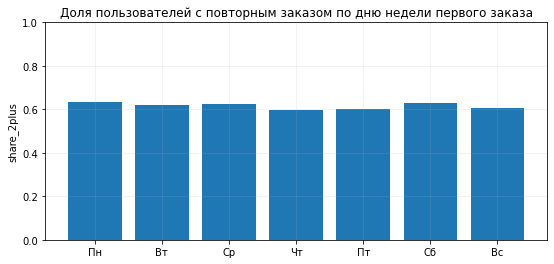

In [28]:

prof = profile_f if "profile_f" in globals() else profile

prof["first_weekday_num"] = pd.to_datetime(prof["first_order_dt"]).dt.dayofweek
map_ru = {0:"Пн",1:"Вт",2:"Ср",3:"Чт",4:"Пт",5:"Сб",6:"Вс"}
prof["first_weekday"] = prof["first_weekday_num"].map(map_ru)

overall_share = prof["is_two"].mean()

res = (prof.groupby("first_weekday", observed=True)
          .agg(users=("user_id","count"), share_2plus=("is_two","mean"))
          .reindex(["Пн","Вт","Ср","Чт","Пт","Сб","Вс"])
       )

print("overall share >=2:", overall_share)
display(res)

plt.figure(figsize=(9,4))
plt.bar(res.index.astype(str), res["share_2plus"])
plt.ylim(0, 1)
plt.title("Доля пользователей с повторным заказом по дню недели первого заказа")
plt.ylabel("share_2plus")
plt.grid(alpha=0.2)
plt.show()

Доли повторных покупок по дням недели почти одинаковые и все близки к общему среднему 0.616. Наблюдается небольшой разброс: максимум у Пн (0.632) и Сб (0.631), минимум у Чт (0.596). Но разница умеренная, поэтому сильного влияния дня недели первой покупки на вероятность возврата не видно



---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [29]:
prof = profile_f if "profile_f" in globals() else profile

# 2–4 заказа
g_2_4 = prof[prof["total_orders"].between(2, 4)].copy()
# 5+ заказов
g_5p  = prof[prof["total_orders"] >= 5].copy()

print("2-4 users:", len(g_2_4), " | 5+ users:", len(g_5p))

print("\n2-4 orders: mean avg_time_between_orders =", g_2_4["avg_time_between_orders"].mean())
print("2-4 orders: median =", g_2_4["avg_time_between_orders"].median())

print("\n5+ orders: mean avg_time_between_orders =", g_5p["avg_time_between_orders"].mean())
print("5+ orders: median =", g_5p["avg_time_between_orders"].median())

2-4 users: 7095  | 5+ users: 6116

2-4 orders: mean avg_time_between_orders = 21.519446981116072
2-4 orders: median = 9.284890046296297

5+ orders: mean avg_time_between_orders = 9.990881524038823
5+ orders: median = 8.225219796118234


Связь видна: у пользователей с 5+ заказами средний интервал между заказами меньше (mean ≈ 9.99 дней, median ≈ 8.23) по сравнению с группой 2–4 заказа (mean ≈ 21.52, median ≈ 9.28).
Вывод: чем короче средний интервал между покупками, тем выше вероятность накопить много повторных заказов (группа 5+ удерживается чаще при более частых визитах).


---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

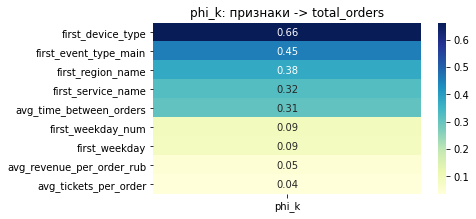

first_device_type            0.661675
first_event_type_main        0.454601
first_region_name            0.377863
first_service_name           0.324332
avg_time_between_orders      0.308777
first_weekday_num            0.089841
first_weekday                0.086399
avg_revenue_per_order_rub    0.045438
avg_tickets_per_order        0.035348
dtype: float64

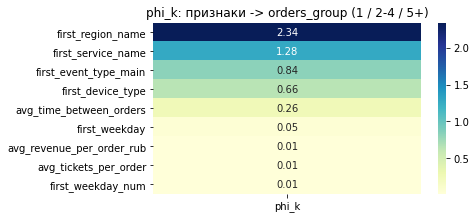

first_region_name            2.342578
first_service_name           1.281640
first_event_type_main        0.839649
first_device_type            0.658140
avg_time_between_orders      0.256840
first_weekday                0.049157
avg_revenue_per_order_rub    0.012821
avg_tickets_per_order        0.012807
first_weekday_num            0.011755
dtype: float64

In [30]:


prof = profile_f if "profile_f" in globals() else profile

interval_cols = ["avg_revenue_per_order_rub", "avg_tickets_per_order", "avg_time_between_orders"]

exclude = {"user_id", "total_orders", "is_two", "is_five", "first_order_dt", "last_order_dt"}
features = [c for c in prof.columns if c not in exclude]

def cramers_v(x, y):
    x = x.astype(str)
    y = y.astype(str)
    tab = pd.crosstab(x, y)
    chi2 = ((tab - tab.mean())**2 / tab.mean()).sum().sum()  # fallback без scipy
    n = tab.sum().sum()
    if n == 0:
        return np.nan
    k = tab.shape[0]
    r = tab.shape[1]
    denom = min(k - 1, r - 1)
    if denom <= 0:
        return 0.0
    phi2 = chi2 / n
    return np.sqrt(phi2 / denom)

def correlation_ratio(cat, num):
    # eta: корреляционное отношение (cat — дискретная категория)
    cat = cat.astype(str)
    num = pd.to_numeric(num, errors="coerce")
    mask = num.notna() & cat.notna()
    cat, num = cat[mask], num[mask]
    if num.empty:
        return np.nan
    mean_total = num.mean()
    ss_total = ((num - mean_total) ** 2).sum()
    if ss_total == 0:
        return 0.0
    ss_between = 0.0
    for c in cat.unique():
        n_c = (cat == c).sum()
        mean_c = num[cat == c].mean()
        ss_between += n_c * (mean_c - mean_total) ** 2
    return np.sqrt(ss_between / ss_total)

def compute_phi_k(target_series):
    out = {}
    for feat in features:
        x = prof[feat]
        y = target_series
        mask = x.notna() & y.notna()
        x2, y2 = x[mask], y[mask]
        if x2.empty:
            out[feat] = np.nan
            continue

        if feat in interval_cols or pd.api.types.is_numeric_dtype(x2):
            out[feat] = correlation_ratio(y2, x2)
        else:
            out[feat] = cramers_v(x2, y2)
    return pd.Series(out).sort_values(ascending=False)

phi_total = compute_phi_k(prof["total_orders"])
plt.figure(figsize=(6, max(3, 0.35 * len(phi_total))))
sns.heatmap(phi_total.to_frame("phi_k"), annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("phi_k: признаки -> total_orders")
plt.show()
display(phi_total.head(10))

def orders_group(n):
    if n == 1:
        return "1"
    if 2 <= n <= 4:
        return "2-4"
    return "5+"

prof = prof.copy()
prof["orders_group"] = prof["total_orders"].apply(orders_group)

phi_group = compute_phi_k(prof["orders_group"])
plt.figure(figsize=(6, max(3, 0.35 * len(phi_group))))
sns.heatmap(phi_group.to_frame("phi_k"), annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("phi_k: признаки -> orders_group (1 / 2-4 / 5+)")
plt.show()
display(phi_group.head(10))

Согласно тепловым картам и значениям корреляции, с количеством заказов (total_orders) наиболее тесно связаны следующие признаки:

first_device_type (0.662) — самая сильная связь.

first_event_type_main (0.455).

Далее по убыванию: first_region_name (0.378), first_service_name (0.324) и avg_time_between_orders (0.309).

После группировки по числу заказов (orders_group) иерархия влияния признаков сохраняется, и топ остается практически неизменным:

first_region_name (2.34) и first_service_name (1.28) — демонстрируют наибольшие значения.

first_event_type_main (0.84) и first_device_type (0.66).

avg_time_between_orders (0.257) — связь заметна, но выражена слабее остальны

У пользователей с разным количеством заказов в профиле различаются в первую очередь  характеристики: тип устройства, категория первого мероприятия, регион и билетный оператор. Временные характеристики (средний интервал между заказами) имеют вторичное значение и связаны с активностью пользователя слабее.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

Данные и подготовка:

days_since_prev рассчитан через LAG, для первой покупки — NULL.
Выручка приведена к рублям. Добавлена колонка revenue_rub.
Проведена нормализация категорий и корректировка типов данных. Пропуски только в days_since_prev.
Выбросы по revenue_rub отфильтрованы по 99-перцентилю (удалено 2 825 строк, осталось 288 024).

Профиль пользователей:

Всего: 21 940.
Доля повторов: ≥2 заказа — 61,6 %, ≥5 заказов — 28,9 %.
Основные факторы числа покупок: first_device_type, first_event_type_main, first_region_name, first_service_name.

Состав заказов и временные закономерности:

Среднее число билетов 2–3  чаще возвращаются; 1–2 билета  реже.
Более короткий интервал между заказами  выше вероятность лояльности.
День недели первой покупки почти не влияет.

Рекомендации:

Сегментация: фокус на "правильных" устройствах и типах мероприятий.
Удержание: точечные предложения на 2-й заказ для слабых сегментов, учитывая средние интервалы между покупками.
Тестирование: малые сегменты с высокой лояльностью проверять через локальные A/B-тесты.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**